In [ ]:
# =============================================================================
# OmniFold unfolding of J/psi in ultra-peripheral Pb-Pb collisions
# Process: coherent J/psi -> mu+ mu- at midrapidity
# MC production: LHC25g15 (STARlight + GEANT4 via O2)
#
# Supports 1D–4D unfolding, controlled by the NDIM switch:
#   NDIM = 1 : pT^2
#   NDIM = 2 : pT^2, delta-pT
#   NDIM = 3 : pT^2, delta-pT, rapidity
#   NDIM = 4 : pT^2, delta-pT, rapidity, cos(theta*) helicity
#
# Pipeline:
#   1. Load the MC TTree and validate branches
#   2. Compute J/psi invariant mass, pT^2, delta-pT, rapidity, cos(theta*)
#   3. Apply fiducial pT^2 cut, then split 80% MC / 20% pseudodata
#   4. Plot migration (purity + efficiency) BEFORE unfolding
#   5. Run OmniFold (MultiFold) with two MLP classifiers
#   6. Plot migration AFTER unfolding and closure test vs pseudodata truth
# =============================================================================

import numpy as np
import uproot
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split

import omnifold as of
from omnifold import MultiFold

In [ ]:
# =============================================================================
# Analysis constants — single source of truth
# =============================================================================
ROOT_FILE = "TTTT.LHC25g15.kCohJpsiToMu.HY639424.root"
TREE_PATH = "DF_2338652700415296/O2truetwotrack"

M_MU     = 0.105658            # muon mass [GeV/c^2]
PT2_CUT  = 0.11 ** 2           # fiducial pT^2 cut [GeV^2/c^2] -> 0.0121
BINS     = [0, 0.001, 0.002, 0.004, 0.006, 0.008, 0.012]
RNG_SEED = 42                  # for the train/test split

# --- Dimensionality switch ---
# NDIM = 1 : pT^2 only
# NDIM = 2 : + delta-pT between tracks
# NDIM = 3 : + rapidity of the pair
# NDIM = 4 : + cos(theta*) helicity angle
NDIM = 1
BINS_DPT = np.linspace(0, 0.5, 21)       # delta-pT bins [GeV/c]  (NDIM >= 2)
BINS_Y   = np.linspace(-0.8, 0.8, 9)    # rapidity bins           (NDIM >= 3)
BINS_COS = np.linspace(-1, 1, 11)         # cos(theta*) bins        (NDIM >= 4)

In [3]:
# =============================================================================
# Load the MC ROOT file produced by the O2 analysis task.
# TTree "O2truetwotrack" contains matched (gen, reco) pairs for
# coherent J/psi -> mu+ mu- events. Each entry has exactly 2 daughters.
# =============================================================================
rootfile = uproot.open(ROOT_FILE)
tree     = rootfile[TREE_PATH]
data     = tree.arrays(library="np")

print(f"Entries: {tree.num_entries}")
print(f"Branches: {list(data.keys())}")

Entries: 6698050
Branches: ['fRunNumber', 'fBc', 'fTotalTracks', 'fNumContrib', 'fGlobalNonPVtracks', 'fPosX', 'fPosY', 'fPosZ', 'fRecoMode', 'fOccupancyInTime', 'fHadronicRate', 'fTrs', 'fTrofs', 'fHmpr', 'fTfb', 'fItsRofb', 'fSbp', 'fZvtxFT0vsPv', 'fVtxITSTPC', 'fTotalFT0AmplitudeA', 'fTotalFT0AmplitudeC', 'fTotalFV0AmplitudeA', 'fEnergyCommonZNA', 'fEnergyCommonZNC', 'fTimeFT0A', 'fTimeFT0C', 'fTimeFV0A', 'fTimeZNA', 'fTimeZNC', 'fTrkPx', 'fTrkPy', 'fTrkPz', 'fTrkSign', 'fTrkDCAxy', 'fTrkDCAz', 'fTrkTimeRes', 'fTrk1ITSclusterSizes', 'fTrk2ITSclusterSizes', 'fTrkTPCsignal', 'fTrkTPCnSigmaEl', 'fTrkTPCnSigmaMu', 'fTrkTPCnSigmaPi', 'fTrkTPCnSigmaKa', 'fTrkTPCnSigmaPr', 'fTrkTPCinnerParam', 'fTrkTOFsignal', 'fTrkTOFnSigmaEl', 'fTrkTOFnSigmaMu', 'fTrkTOFnSigmaPi', 'fTrkTOFnSigmaKa', 'fTrkTOFnSigmaPr', 'fTrkTOFexpMom', 'fTrueChannel', 'fTrueHasRecoColl', 'fTruePosX', 'fTruePosY', 'fTruePosZ', 'fTrueMotherPx', 'fTrueMotherPy', 'fTrueMotherPz', 'fTrueDaugPx', 'fTrueDaugPy', 'fTrueDaugPz', '

In [4]:
# =============================================================================
# Validate that every track-like branch (Trk, Daug, Mother) has exactly
# 2 elements per entry — one per muon daughter. Guards against variable-
# length arrays that would break the fixed-index slicing ([:, 0], [:, 1]).
# =============================================================================
track_branches = [k for k in data if any(t in k for t in ("Trk", "Daug", "Mother"))]
print(f"Track-like branches: {track_branches}")

for branch in track_branches:
    arr = data[branch]
    if hasattr(arr[0], "__len__"):
        bad = [i for i, e in enumerate(arr) if len(e) != 2]
        if bad:
            print(f"  {branch}: {len(bad)} entries do NOT have 2 elements (first 5: {bad[:5]})")
        else:
            print(f"  {branch}: OK — all {len(arr)} entries have exactly 2 elements")
    else:
        print(f"  {branch}: scalar (not an array per entry)")

Track-like branches: ['fTrkPx', 'fTrkPy', 'fTrkPz', 'fTrkSign', 'fTrkDCAxy', 'fTrkDCAz', 'fTrkTimeRes', 'fTrk1ITSclusterSizes', 'fTrk2ITSclusterSizes', 'fTrkTPCsignal', 'fTrkTPCnSigmaEl', 'fTrkTPCnSigmaMu', 'fTrkTPCnSigmaPi', 'fTrkTPCnSigmaKa', 'fTrkTPCnSigmaPr', 'fTrkTPCinnerParam', 'fTrkTOFsignal', 'fTrkTOFnSigmaEl', 'fTrkTOFnSigmaMu', 'fTrkTOFnSigmaPi', 'fTrkTOFnSigmaKa', 'fTrkTOFnSigmaPr', 'fTrkTOFexpMom', 'fTrueMotherPx', 'fTrueMotherPy', 'fTrueMotherPz', 'fTrueDaugPx', 'fTrueDaugPy', 'fTrueDaugPz', 'fTrueDaugPdgCode']
  fTrkPx: OK — all 6698050 entries have exactly 2 elements
  fTrkPy: OK — all 6698050 entries have exactly 2 elements
  fTrkPz: OK — all 6698050 entries have exactly 2 elements
  fTrkSign: OK — all 6698050 entries have exactly 2 elements
  fTrkDCAxy: OK — all 6698050 entries have exactly 2 elements
  fTrkDCAz: OK — all 6698050 entries have exactly 2 elements
  fTrkTimeRes: OK — all 6698050 entries have exactly 2 elements
  fTrk1ITSclusterSizes: scalar (not an array 

In [ ]:
# =============================================================================
# Helper functions — defined once, reused throughout the notebook.
#
#   invariant_mass(px, py, pz, m)  : (N,2) 4-momenta -> (N,) inv mass
#   pt2_sum(px, py)                : (N,2) -> (N,) squared vector sum pT
#   delta_pt(px, py)               : (N,2) -> (N,) |pT1 - pT2|
#   rapidity(px, py, pz, m)       : (N,2) -> (N,) pair rapidity
#   cos_theta_helicity(px, py, pz, m) : (N,2) -> (N,) cos(theta*) in helicity frame
#   compute_migration(reco, gen, bins, weights=None) -> (purity%, eff%)
#   plot_matrix(mat, bins, title, xlabel, ylabel)
#   plot_mass(m, bins, rng, color, title, log=False)
# =============================================================================

def invariant_mass(px, py, pz, m):
    """Invariant mass of a pair of particles with common mass `m`."""
    e = np.sqrt(px**2 + py**2 + pz**2 + m**2)
    s = (e.sum(axis=1)**2
         - px.sum(axis=1)**2 - py.sum(axis=1)**2 - pz.sum(axis=1)**2)
    return np.sqrt(np.clip(s, 0.0, None))

def pt2_sum(px, py):
    """Squared pT of the vector sum of a pair."""
    return px.sum(axis=1)**2 + py.sum(axis=1)**2

def delta_pt(px, py):
    """Absolute pT difference between two daughter tracks: |pT1 - pT2|."""
    pt = np.sqrt(px**2 + py**2)          # (N, 2)
    return np.abs(pt[:, 0] - pt[:, 1])   # (N,)

def rapidity(px, py, pz, m):
    """Rapidity of the pair."""
    e = np.sqrt(px**2 + py**2 + pz**2 + m**2)   # (N, 2)
    E_pair  = e.sum(axis=1)
    pz_pair = pz.sum(axis=1)
    return 0.5 * np.log((E_pair + pz_pair) / (E_pair - pz_pair))

def cos_theta_helicity(px, py, pz, m):
    """cos(theta*) of the mu+ in the helicity frame of the pair.

    The helicity frame is the pair rest frame with z-axis along the
    pair momentum direction in the lab. We boost the mu+ (daughter 0)
    into the pair rest frame and compute cos(theta) w.r.t. the pair
    flight direction.
    """
    e = np.sqrt(px**2 + py**2 + pz**2 + m**2)  # (N, 2)
    # Pair 4-momentum
    E_pair  = e.sum(axis=1)
    px_pair = px.sum(axis=1)
    py_pair = py.sum(axis=1)
    pz_pair = pz.sum(axis=1)
    M_pair  = np.sqrt(np.clip(E_pair**2 - px_pair**2 - py_pair**2 - pz_pair**2, 0, None))

    # Pair momentum magnitude
    p_pair = np.sqrt(px_pair**2 + py_pair**2 + pz_pair**2)

    # Boost parameters (pair velocity)
    beta  = p_pair / E_pair
    gamma = E_pair / np.clip(M_pair, 1e-12, None)

    # Unit vector along pair momentum (helicity z-axis)
    ux = px_pair / np.clip(p_pair, 1e-12, None)
    uy = py_pair / np.clip(p_pair, 1e-12, None)
    uz = pz_pair / np.clip(p_pair, 1e-12, None)

    # Daughter-0 (mu+) momentum component along pair direction
    p1_par = px[:, 0]*ux + py[:, 0]*uy + pz[:, 0]*uz

    # Lorentz boost of the parallel component into the pair rest frame
    e1 = e[:, 0]
    p1_par_star = gamma * (p1_par - beta * e1)

    # Daughter momentum magnitude in the rest frame (use invariant)
    # |p*| = sqrt(M^2/4 - m^2), but compute directly for robustness
    p1_perp2 = (px[:, 0]**2 + py[:, 0]**2 + pz[:, 0]**2) - p1_par**2
    p1_perp2 = np.clip(p1_perp2, 0, None)
    p1_star = np.sqrt(p1_par_star**2 + p1_perp2)

    return p1_par_star / np.clip(p1_star, 1e-12, None)

def compute_migration(reco_arr, gen_arr, bins, weights=None):
    """Return (purity%, efficiency%) migration matrices for a (reco, gen) pair."""
    n_bins = len(bins) - 1
    mig = np.zeros((n_bins, n_bins))
    idx_r = np.digitize(reco_arr, bins) - 1
    idx_g = np.digitize(gen_arr,  bins) - 1
    if weights is None:
        weights = np.ones(len(reco_arr))
    for r, g, w in zip(idx_r, idx_g, weights):
        if 0 <= r < n_bins and 0 <= g < n_bins:
            mig[r, g] += w

    purity = np.zeros_like(mig)
    for r in range(n_bins):
        s = mig[r, :].sum()
        if s > 0:
            purity[r, :] = mig[r, :] / s * 100

    efficiency = np.zeros_like(mig)
    for g in range(n_bins):
        s = mig[:, g].sum()
        if s > 0:
            efficiency[:, g] = mig[:, g] / s * 100

    return purity, efficiency

def plot_matrix(matrix, bins, title, xlabel, ylabel):
    """Plot a normalized (%) migration matrix as an annotated heatmap."""
    n_bins = len(bins) - 1
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(matrix.T, origin="lower", aspect="auto",
                   extent=[0, n_bins, 0, n_bins], cmap="Blues", vmin=0, vmax=100)
    plt.colorbar(im, ax=ax, label="%")
    for r in range(n_bins):
        for g in range(n_bins):
            val = matrix[r, g]
            ax.text(r + 0.5, g + 0.5, f"{val:.1f}%",
                    ha="center", va="center", fontsize=9,
                    color="white" if val > 50 else "black")
    labels = [f"{bins[i]:.4g}-{bins[i+1]:.4g}" for i in range(n_bins)]
    ax.set_xticks(np.arange(n_bins) + 0.5); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(np.arange(n_bins) + 0.5); ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    plt.tight_layout(); plt.show()

def plot_mass(m, bins, rng, color, title, log=False):
    """Stand-alone invariant mass sanity plot."""
    plt.figure()
    plt.hist(m, bins=bins, range=rng, histtype="step", color=color)
    plt.xlabel(r"$M_{\mu\mu}$ [GeV]"); plt.ylabel("Entries")
    if log:
        plt.yscale("log")
    plt.title(title)
    plt.show()

In [ ]:
# =============================================================================
# Compute gen- and reco-level J/psi observables for the full sample, once.
#
#   pT^2         = (px1+px2)^2 + (py1+py2)^2   (pair vector-sum pT squared)
#   delta_pT     = |pT_trk1 - pT_trk2|         (single-track pT asymmetry)
#   y            = pair rapidity
#   cos(theta*)  = helicity angle of mu+ in pair rest frame
# =============================================================================
inv_mass_gen  = invariant_mass(data["fTrueDaugPx"], data["fTrueDaugPy"],
                               data["fTrueDaugPz"], M_MU)
inv_mass_reco = invariant_mass(data["fTrkPx"],      data["fTrkPy"],
                               data["fTrkPz"],      M_MU)

pt2_gen  = pt2_sum(data["fTrueDaugPx"], data["fTrueDaugPy"])
pt2_reco = pt2_sum(data["fTrkPx"],      data["fTrkPy"])

dpt_gen  = delta_pt(data["fTrueDaugPx"], data["fTrueDaugPy"])
dpt_reco = delta_pt(data["fTrkPx"],      data["fTrkPy"])

y_gen  = rapidity(data["fTrueDaugPx"], data["fTrueDaugPy"],
                  data["fTrueDaugPz"], M_MU)
y_reco = rapidity(data["fTrkPx"],      data["fTrkPy"],
                  data["fTrkPz"],      M_MU)

costh_gen  = cos_theta_helicity(data["fTrueDaugPx"], data["fTrueDaugPy"],
                                data["fTrueDaugPz"], M_MU)
costh_reco = cos_theta_helicity(data["fTrkPx"],      data["fTrkPy"],
                                data["fTrkPz"],      M_MU)

print(f"Computed observables for {len(pt2_gen)} events.")
print(f"  pT^2        gen  range: [{pt2_gen.min():.6f}, {pt2_gen.max():.4f}]")
print(f"  dpt         gen  range: [{dpt_gen.min():.4f}, {dpt_gen.max():.4f}]")
print(f"  y           gen  range: [{y_gen.min():.4f}, {y_gen.max():.4f}]")
print(f"  cos(theta*) gen  range: [{costh_gen.min():.4f}, {costh_gen.max():.4f}]")

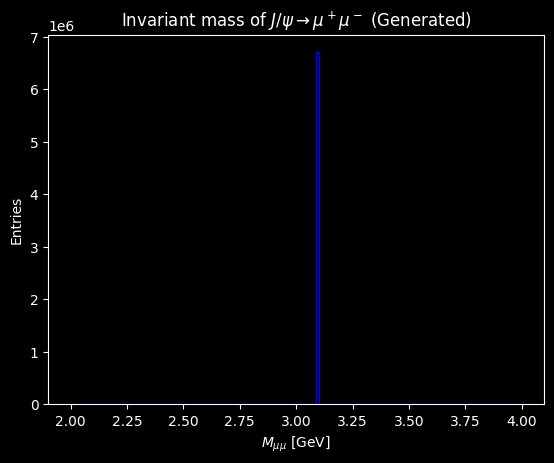

In [7]:
# Sanity: generated invariant mass should peak at M(J/psi) ~ 3.097 GeV.
plot_mass(inv_mass_gen, bins=200, rng=(2.0, 4.0), color="blue",
          title=r"Invariant mass of $J/\psi \to \mu^+\mu^-$ (Generated)")

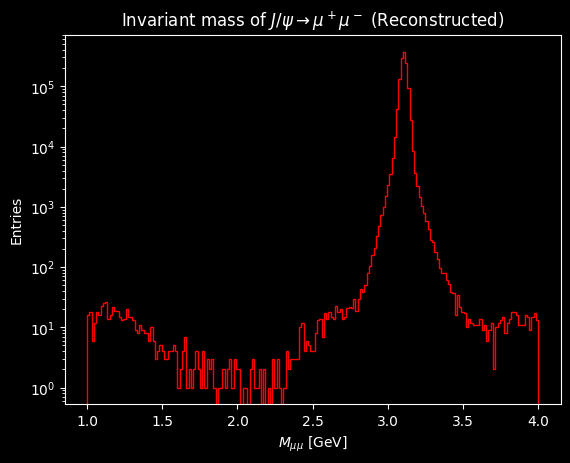

In [8]:
# Sanity: reconstructed invariant mass, smeared by detector resolution.
plot_mass(inv_mass_reco, bins=200, rng=(1.0, 4.0), color="red",
          title=r"Invariant mass of $J/\psi \to \mu^+\mu^-$ (Reconstructed)",
          log=True)

In [ ]:
# =============================================================================
# Apply fiducial pT^2 cut to BOTH gen and reco, then split 80% MC / 20% pseudodata.
# Build the observable arrays whose column count matches NDIM.
# =============================================================================
fid          = (pt2_gen < PT2_CUT) & (pt2_reco < PT2_CUT)
fid_indices  = np.where(fid)[0]

idx_mc, idx_test = train_test_split(fid_indices, test_size=0.2, random_state=RNG_SEED)

# --- 1D arrays (always needed for migration plots) ---
mc_pt2_gen,   mc_pt2_reco   = pt2_gen[idx_mc],   pt2_reco[idx_mc]
test_pt2_gen, test_pt2_reco = pt2_gen[idx_test], pt2_reco[idx_test]
mc_dpt_gen,   mc_dpt_reco   = dpt_gen[idx_mc],   dpt_reco[idx_mc]
test_dpt_gen, test_dpt_reco = dpt_gen[idx_test], dpt_reco[idx_test]
mc_y_gen,     mc_y_reco     = y_gen[idx_mc],     y_reco[idx_mc]
test_y_gen,   test_y_reco   = y_gen[idx_test],   y_reco[idx_test]
mc_costh_gen,   mc_costh_reco   = costh_gen[idx_mc],   costh_reco[idx_mc]
test_costh_gen, test_costh_reco = costh_gen[idx_test], costh_reco[idx_test]

# --- Observable arrays fed to OmniFold ---
if NDIM == 1:
    mc_obs_gen,   mc_obs_reco   = mc_pt2_gen,   mc_pt2_reco
    test_obs_gen, test_obs_reco = test_pt2_gen, test_pt2_reco
elif NDIM == 2:
    mc_obs_gen   = np.column_stack([mc_pt2_gen,   mc_dpt_gen])
    mc_obs_reco  = np.column_stack([mc_pt2_reco,  mc_dpt_reco])
    test_obs_gen = np.column_stack([test_pt2_gen, test_dpt_gen])
    test_obs_reco = np.column_stack([test_pt2_reco, test_dpt_reco])
elif NDIM == 3:
    mc_obs_gen   = np.column_stack([mc_pt2_gen,   mc_dpt_gen,   mc_y_gen])
    mc_obs_reco  = np.column_stack([mc_pt2_reco,  mc_dpt_reco,  mc_y_reco])
    test_obs_gen = np.column_stack([test_pt2_gen, test_dpt_gen, test_y_gen])
    test_obs_reco = np.column_stack([test_pt2_reco, test_dpt_reco, test_y_reco])
elif NDIM == 4:
    mc_obs_gen   = np.column_stack([mc_pt2_gen,   mc_dpt_gen,   mc_y_gen,   mc_costh_gen])
    mc_obs_reco  = np.column_stack([mc_pt2_reco,  mc_dpt_reco,  mc_y_reco,  mc_costh_reco])
    test_obs_gen = np.column_stack([test_pt2_gen, test_dpt_gen, test_y_gen, test_costh_gen])
    test_obs_reco = np.column_stack([test_pt2_reco, test_dpt_reco, test_y_reco, test_costh_reco])

print(f"NDIM = {NDIM}")
print(f"MC (training)     events after fiducial cut: {len(mc_pt2_gen)}")
print(f"Pseudodata (test) events after fiducial cut: {len(test_pt2_gen)}")
print(f"Observable array shape (MC gen): {mc_obs_gen.shape}")

In [ ]:
# =============================================================================
# Purity and efficiency BEFORE unfolding (unweighted MC training sample).
# Always shown per variable (pT^2, and additional variables when NDIM >= 2).
# =============================================================================
purity_before, eff_before = compute_migration(mc_pt2_reco, mc_pt2_gen, BINS)

plot_matrix(purity_before, BINS,
    r"Purity BEFORE unfolding — $p_T^2$ (per reco bin)",
    r"Reco $p_T^2$ bin [GeV$^2/c^2$]",
    r"Gen $p_T^2$ bin [GeV$^2/c^2$]")
plot_matrix(eff_before, BINS,
    r"Efficiency BEFORE unfolding — $p_T^2$ (per gen bin)",
    r"Reco $p_T^2$ bin [GeV$^2/c^2$]",
    r"Gen $p_T^2$ bin [GeV$^2/c^2$]")

if NDIM >= 2:
    pur_dpt_b, eff_dpt_b = compute_migration(mc_dpt_reco, mc_dpt_gen, BINS_DPT)
    plot_matrix(pur_dpt_b, BINS_DPT,
        r"Purity BEFORE unfolding — $\Delta p_T$ (per reco bin)",
        r"Reco $\Delta p_T$ bin [GeV/$c$]",
        r"Gen $\Delta p_T$ bin [GeV/$c$]")
    plot_matrix(eff_dpt_b, BINS_DPT,
        r"Efficiency BEFORE unfolding — $\Delta p_T$ (per gen bin)",
        r"Reco $\Delta p_T$ bin [GeV/$c$]",
        r"Gen $\Delta p_T$ bin [GeV/$c$]")

if NDIM >= 3:
    pur_y_b, eff_y_b = compute_migration(mc_y_reco, mc_y_gen, BINS_Y)
    plot_matrix(pur_y_b, BINS_Y,
        r"Purity BEFORE unfolding — $y$ (per reco bin)",
        r"Reco $y$ bin", r"Gen $y$ bin")
    plot_matrix(eff_y_b, BINS_Y,
        r"Efficiency BEFORE unfolding — $y$ (per gen bin)",
        r"Reco $y$ bin", r"Gen $y$ bin")

if NDIM >= 4:
    pur_cos_b, eff_cos_b = compute_migration(mc_costh_reco, mc_costh_gen, BINS_COS)
    plot_matrix(pur_cos_b, BINS_COS,
        r"Purity BEFORE unfolding — $\cos\theta^*$ (per reco bin)",
        r"Reco $\cos\theta^*$ bin", r"Gen $\cos\theta^*$ bin")
    plot_matrix(eff_cos_b, BINS_COS,
        r"Efficiency BEFORE unfolding — $\cos\theta^*$ (per gen bin)",
        r"Reco $\cos\theta^*$ bin", r"Gen $\cos\theta^*$ bin")

In [11]:
# =============================================================================
# Build the OmniFold DataLoaders and two MLP classifiers.
# Observable arrays are (N,) for NDIM=1, (N,2) for NDIM=2.
# =============================================================================
pseudo_data = of.DataLoader(reco=test_obs_reco, normalize=True)
training_mc = of.DataLoader(reco=mc_obs_reco, gen=mc_obs_gen, normalize=True)

model1 = of.MLP(NDIM)
model2 = of.MLP(NDIM)

INFO: Creating weights ...
INFO: Creating pass reco flag ...
INFO: Normalizing sum of weights to 1000000 ...
INFO: Creating weights ...
INFO: Creating pass reco flag ...
INFO: Creating pass gen flag ...
INFO: Normalizing sum of weights to 1000000 ...


In [12]:
# =============================================================================
# Run OmniFold (MultiFold). Each iteration does two steps:
#   Step 1 (pull): reweight MC reco -> data reco via model1
#   Step 2 (push): reweight MC gen  -> reweighted MC gen via model2
# After niter iterations the push weights applied to MC gen approximate the
# true gen-level distribution that produced the observed (pseudo)data.
# =============================================================================
omnifold_object = MultiFold(
    "JpsiPt2Mid",
    model1,
    model2,
    pseudo_data,
    training_mc,
    batch_size     = 512,
    niter          = 5,
    epochs         = 10,
    weights_folder = "weights",
    verbose        = True,
    lr             = 5e-5,
)
omnifold_object.Unfold()

2286 training steps at reco and 3658 steps at gen
ITERATION: 1
RUNNING STEP 1
Creating cached data from step 1
################################################################################
Train events used: 1170432, Test events used: 234086
################################################################################
Epoch 1/10
1828/1828 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1.1844 - val_loss: 1.1838 - learning_rate: 5.0000e-05
Epoch 2/10
1828/1828 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.1845 - val_loss: 1.1838 - learning_rate: 5.0000e-05
Epoch 3/10
1828/1828 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.1844 - val_loss: 1.1838 - learning_rate: 5.0000e-05
Epoch 4/10
1828/1828 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.1844 - val_loss: 1.1838 - learning_rate: 5.0000e-05
Epoch 5/10
1828/1828 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.1845 - val_loss: 1.1838 - learning_rate: 5.0000e-05
Epoch 6/10
1828/1828 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 1.1844 - val_loss: 1.1838 - lear

In [13]:
# Final push weights, one per MC gen event. Applying these to `mc_pt2_gen`
# gives the unfolded distribution. (Equivalent to
# omnifold_object.reweight(training_mc.gen, omnifold_object.model2, batch_size=1000).)
w_unfolded = omnifold_object.weights_push

assert w_unfolded.shape == mc_pt2_gen.shape, (
    f"weights ({w_unfolded.shape}) vs mc_pt2_gen ({mc_pt2_gen.shape}) mismatch"
)
print(f"Unfolded weights: shape={w_unfolded.shape}, sum={w_unfolded.sum():.1f}")

Unfolded weights: shape=(936454,), sum=938333.7


In [ ]:
# =============================================================================
# Purity and efficiency AFTER unfolding (per-variable projections).
# =============================================================================
purity_after, eff_after = compute_migration(mc_pt2_reco, mc_pt2_gen, BINS,
                                            weights=w_unfolded)

plot_matrix(purity_after, BINS,
    r"Purity AFTER unfolding — $p_T^2$ (per reco bin)",
    r"Reco $p_T^2$ bin [GeV$^2/c^2$]",
    r"Gen $p_T^2$ bin [GeV$^2/c^2$]")
plot_matrix(eff_after, BINS,
    r"Efficiency AFTER unfolding — $p_T^2$ (per gen bin)",
    r"Reco $p_T^2$ bin [GeV$^2/c^2$]",
    r"Gen $p_T^2$ bin [GeV$^2/c^2$]")

if NDIM >= 2:
    pur_dpt_a, eff_dpt_a = compute_migration(mc_dpt_reco, mc_dpt_gen, BINS_DPT,
                                              weights=w_unfolded)
    plot_matrix(pur_dpt_a, BINS_DPT,
        r"Purity AFTER unfolding — $\Delta p_T$ (per reco bin)",
        r"Reco $\Delta p_T$ bin [GeV/$c$]",
        r"Gen $\Delta p_T$ bin [GeV/$c$]")
    plot_matrix(eff_dpt_a, BINS_DPT,
        r"Efficiency AFTER unfolding — $\Delta p_T$ (per gen bin)",
        r"Reco $\Delta p_T$ bin [GeV/$c$]",
        r"Gen $\Delta p_T$ bin [GeV/$c$]")

if NDIM >= 3:
    pur_y_a, eff_y_a = compute_migration(mc_y_reco, mc_y_gen, BINS_Y,
                                          weights=w_unfolded)
    plot_matrix(pur_y_a, BINS_Y,
        r"Purity AFTER unfolding — $y$ (per reco bin)",
        r"Reco $y$ bin", r"Gen $y$ bin")
    plot_matrix(eff_y_a, BINS_Y,
        r"Efficiency AFTER unfolding — $y$ (per gen bin)",
        r"Reco $y$ bin", r"Gen $y$ bin")

if NDIM >= 4:
    pur_cos_a, eff_cos_a = compute_migration(mc_costh_reco, mc_costh_gen, BINS_COS,
                                              weights=w_unfolded)
    plot_matrix(pur_cos_a, BINS_COS,
        r"Purity AFTER unfolding — $\cos\theta^*$ (per reco bin)",
        r"Reco $\cos\theta^*$ bin", r"Gen $\cos\theta^*$ bin")
    plot_matrix(eff_cos_a, BINS_COS,
        r"Efficiency AFTER unfolding — $\cos\theta^*$ (per gen bin)",
        r"Reco $\cos\theta^*$ bin", r"Gen $\cos\theta^*$ bin")

In [ ]:
# =============================================================================
# Closure test: unfolded spectrum vs pseudodata truth (per-variable projections).
# =============================================================================

ndim_tag = f"({NDIM}D unfolding)" if NDIM > 1 else "(1D)"

# --- pT^2 closure (always) ---
plt.figure(figsize=(8, 6))
plt.hist(mc_pt2_gen,   bins=BINS, density=True, histtype="step",
         color="blue",   label="MC gen (training)")
plt.hist(test_pt2_gen, bins=BINS, density=True, histtype="bar",
         color="green",  alpha=0.4, label="Pseudodata truth (target)")
plt.hist(test_pt2_reco, bins=BINS, density=True, histtype="step",
         color="red",    ls=":", label="Pseudodata reco (before unfolding)")
plt.hist(mc_pt2_gen,   bins=BINS, density=True, histtype="step",
         color="orange",  lw=2, weights=w_unfolded, label="OmniFold unfolded")
plt.xlabel(r"$p_T^2$ [GeV$^2/c^2$]")
plt.ylabel("Normalized")
plt.title(rf"$J/\psi$ $p_T^2$ closure {ndim_tag}")
plt.legend(frameon=False)
plt.show()

# --- delta-pT closure (NDIM >= 2) ---
if NDIM >= 2:
    plt.figure(figsize=(8, 6))
    plt.hist(mc_dpt_gen,   bins=BINS_DPT, density=True, histtype="step",
             color="blue",   label="MC gen (training)")
    plt.hist(test_dpt_gen, bins=BINS_DPT, density=True, histtype="bar",
             color="green",  alpha=0.4, label="Pseudodata truth (target)")
    plt.hist(test_dpt_reco, bins=BINS_DPT, density=True, histtype="step",
             color="red",    ls=":", label="Pseudodata reco (before unfolding)")
    plt.hist(mc_dpt_gen,   bins=BINS_DPT, density=True, histtype="step",
             color="orange",  lw=2, weights=w_unfolded, label="OmniFold unfolded")
    plt.xlabel(r"$\Delta p_T$ [GeV/$c$]")
    plt.ylabel("Normalized")
    plt.title(rf"$J/\psi$ $\Delta p_T$ closure {ndim_tag}")
    plt.legend(frameon=False)
    plt.show()

# --- rapidity closure (NDIM >= 3) ---
if NDIM >= 3:
    plt.figure(figsize=(8, 6))
    plt.hist(mc_y_gen,   bins=BINS_Y, density=True, histtype="step",
             color="blue",   label="MC gen (training)")
    plt.hist(test_y_gen, bins=BINS_Y, density=True, histtype="bar",
             color="green",  alpha=0.4, label="Pseudodata truth (target)")
    plt.hist(test_y_reco, bins=BINS_Y, density=True, histtype="step",
             color="red",    ls=":", label="Pseudodata reco (before unfolding)")
    plt.hist(mc_y_gen,   bins=BINS_Y, density=True, histtype="step",
             color="orange",  lw=2, weights=w_unfolded, label="OmniFold unfolded")
    plt.xlabel(r"$y$")
    plt.ylabel("Normalized")
    plt.title(rf"$J/\psi$ rapidity closure {ndim_tag}")
    plt.legend(frameon=False)
    plt.show()

# --- cos(theta*) closure (NDIM >= 4) ---
if NDIM >= 4:
    plt.figure(figsize=(8, 6))
    plt.hist(mc_costh_gen,   bins=BINS_COS, density=True, histtype="step",
             color="blue",   label="MC gen (training)")
    plt.hist(test_costh_gen, bins=BINS_COS, density=True, histtype="bar",
             color="green",  alpha=0.4, label="Pseudodata truth (target)")
    plt.hist(test_costh_reco, bins=BINS_COS, density=True, histtype="step",
             color="red",    ls=":", label="Pseudodata reco (before unfolding)")
    plt.hist(mc_costh_gen,   bins=BINS_COS, density=True, histtype="step",
             color="orange",  lw=2, weights=w_unfolded, label="OmniFold unfolded")
    plt.xlabel(r"$\cos\theta^*$")
    plt.ylabel("Normalized")
    plt.title(rf"$J/\psi$ $\cos\theta^*$ closure {ndim_tag}")
    plt.legend(frameon=False)
    plt.show()